In [1212]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path().resolve().parents[1]))

import data_catalog.data_factory as df_module



In [1213]:
year_map = {
    1: 2022,
    2: 2023,
    3: 2024,
	4: 2025}


In [1214]:
uf_map = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL", 28: "SE", 29: "BA",
    31: "MG", 32: "ES", 33: "RJ", 35: "SP",
    41: "PR", 42: "SC", 43: "RS",
    50: "MS", 51: "MT", 52: "GO", 53: "DF"}

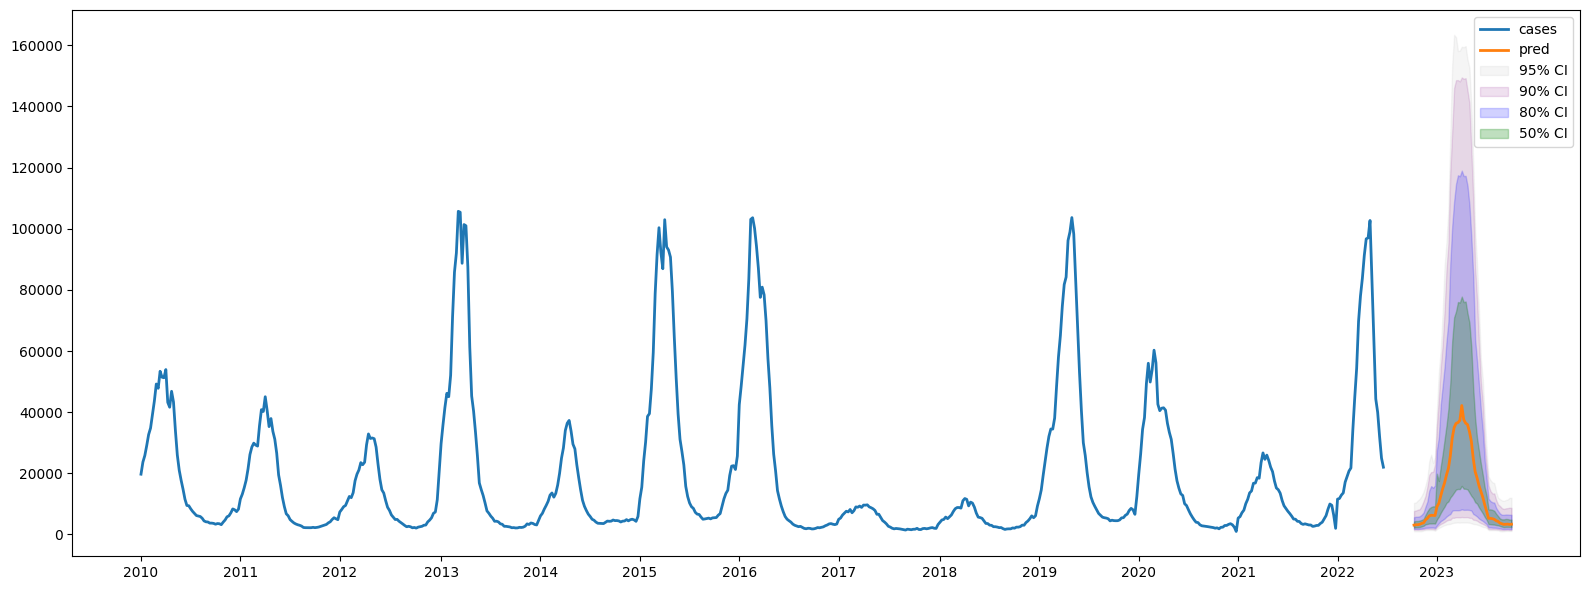

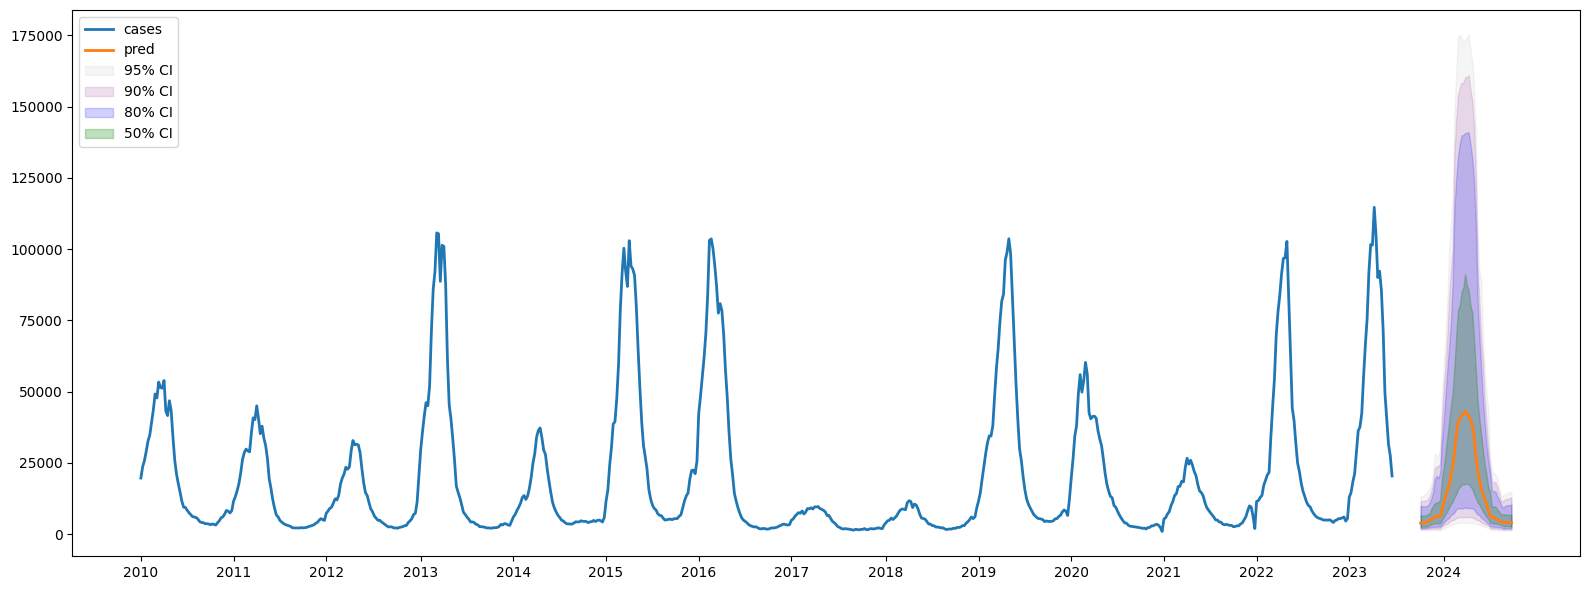

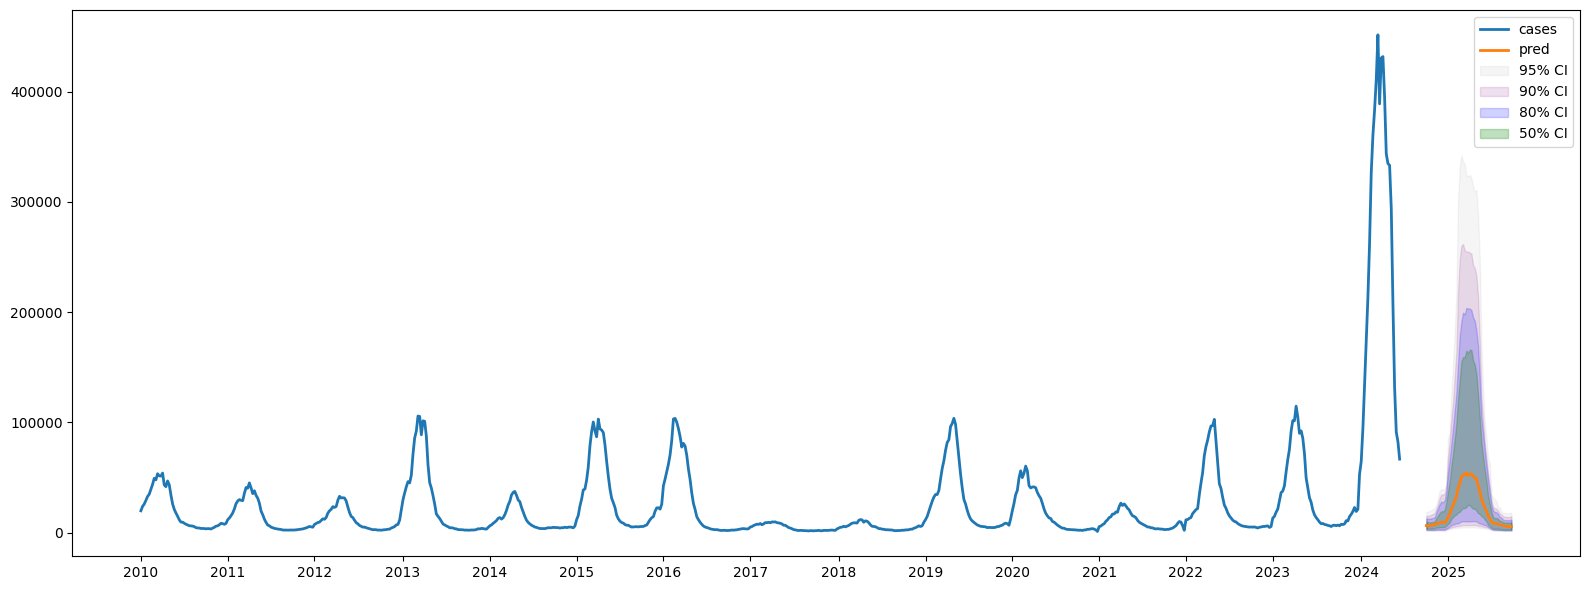

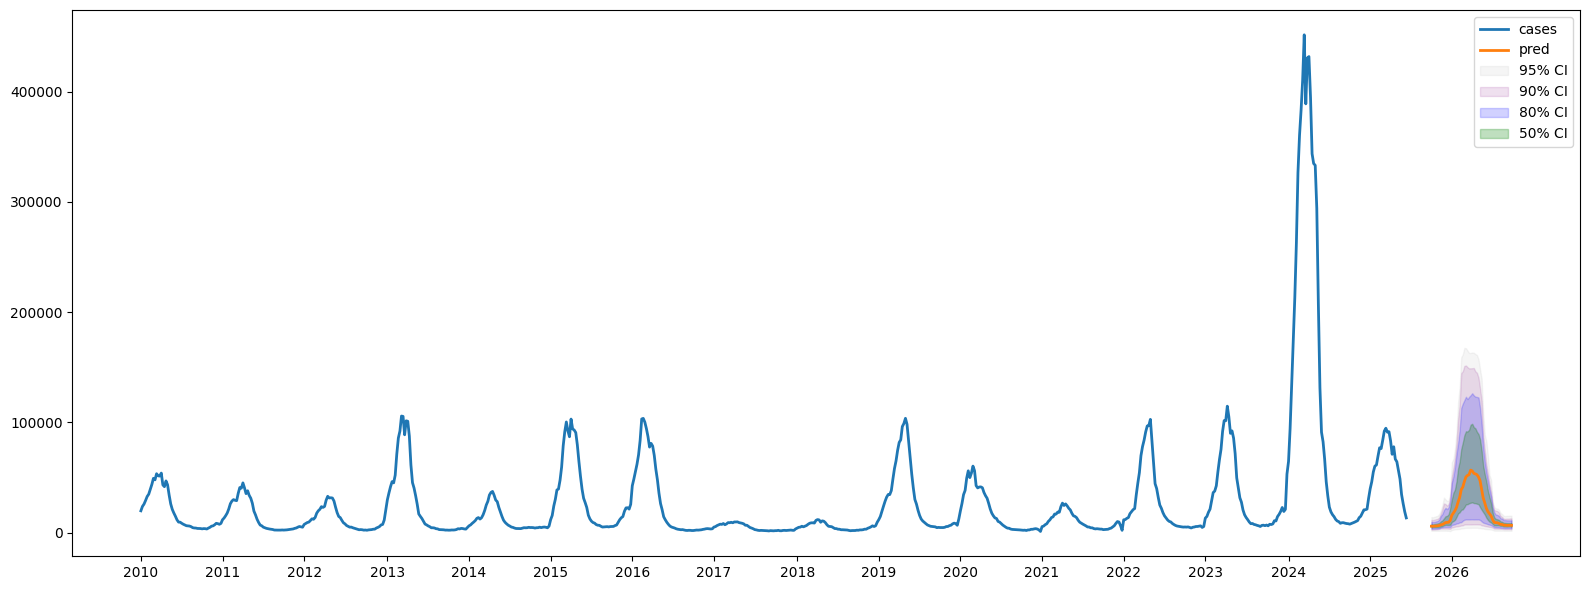

In [ ]:
for TAG in range(1, 5):

    x, y = df_module.data_factory(TAG)

    y = y[['uf_code','date', 'cases']]

    x = x[['uf_code', 'date', 'cases']]
    result_1 = pd.read_csv(f"results/search/final/ds{TAG}_submission.csv")


    dates_to_exclude = result_1["date"].drop_duplicates().head(15)

    result_1 = result_1[~result_1["date"].isin(dates_to_exclude)]

    y = y.sort_values("date")

    dates_to_exclude = y["date"].drop_duplicates().iloc[:15]

    y = y[~y["date"].isin(dates_to_exclude)]

    df = pd.concat([x, y], axis=0, ignore_index=True)

    all_keys = pd.concat([df[["uf_code", "date"]],result_1[["uf_code", "date"]]]).drop_duplicates()
    df_full = all_keys.merge(df, on=["uf_code", "date"], how="left")
    df_full = df_full.merge(
        result_1,
        on=["uf_code", "date"],
        how="left",
        suffixes=("", "_pred")
    )


    for col in result_1.columns:
        if col not in ["uf_code", "date"]:
            df_full[col] = df_full[col + "_pred"] if col + "_pred" in df_full else df_full[col]
    df_full = df_full.drop(columns=[c for c in df_full.columns if c.endswith("_pred")])
    uf_expected = set(df_full["uf_code"].unique())
    df_national = (
        df_full
        .drop(columns=["uf_code"])
        .groupby("date", as_index=False)
        .sum(min_count=len(uf_expected)))


    df_national = df_national.sort_values("date").copy()
    df_national["date"] = pd.to_datetime(df_national["date"], errors="coerce")

    df_national = df_national.set_index("date").asfreq("W").reset_index()

    mask_pred = df_national["pred"].notna()
    df_national.loc[mask_pred, "cases"] = np.nan

    plt.figure(figsize=(16, 6))

    def plot_strict(x, y, label):
        x = pd.to_datetime(x)
        y = np.asarray(y)
        plt.plot(x, y, label=label, linewidth=2)

    plot_strict(df_national["date"], df_national["cases"], "cases")
    plot_strict(df_national["date"], df_national["pred"], "pred")

    plt.fill_between(
        df_national["date"],
        df_national["lower_95"],
        df_national["upper_95"],
        color="gray",
        alpha=0.08,
        label="95% CI"
    )

    plt.fill_between(
        df_national["date"],
        df_national["lower_90"],
        df_national["upper_90"],
        color="purple",
        alpha=0.12,
        label="90% CI"
    )

    plt.fill_between(
        df_national["date"],
        df_national["lower_80"],
        df_national["upper_80"],
        color="blue",
        alpha=0.18,
        label="80% CI"
    )

    plt.fill_between(
        df_national["date"],
        df_national["lower_50"],
        df_national["upper_50"],
        color="green",
        alpha=0.25,
        label="50% CI"
    )

    years = df_national["date"].dt.year
    year_starts = df_national.groupby(years)["date"].min()
    plt.xticks(year_starts, year_starts.dt.year)

    plt.legend()
    plt.tight_layout()
    plt.show()


    year = year_map[TAG]

    result_1["state"] = result_1["uf_code"].map(uf_map)

    result_1 = result_1.drop(columns=["uf_code"])

    path = Path(f"../../submissions/xgboost/test_{TAG}_{year}.csv")

    result_1.to_csv(path, index=False)

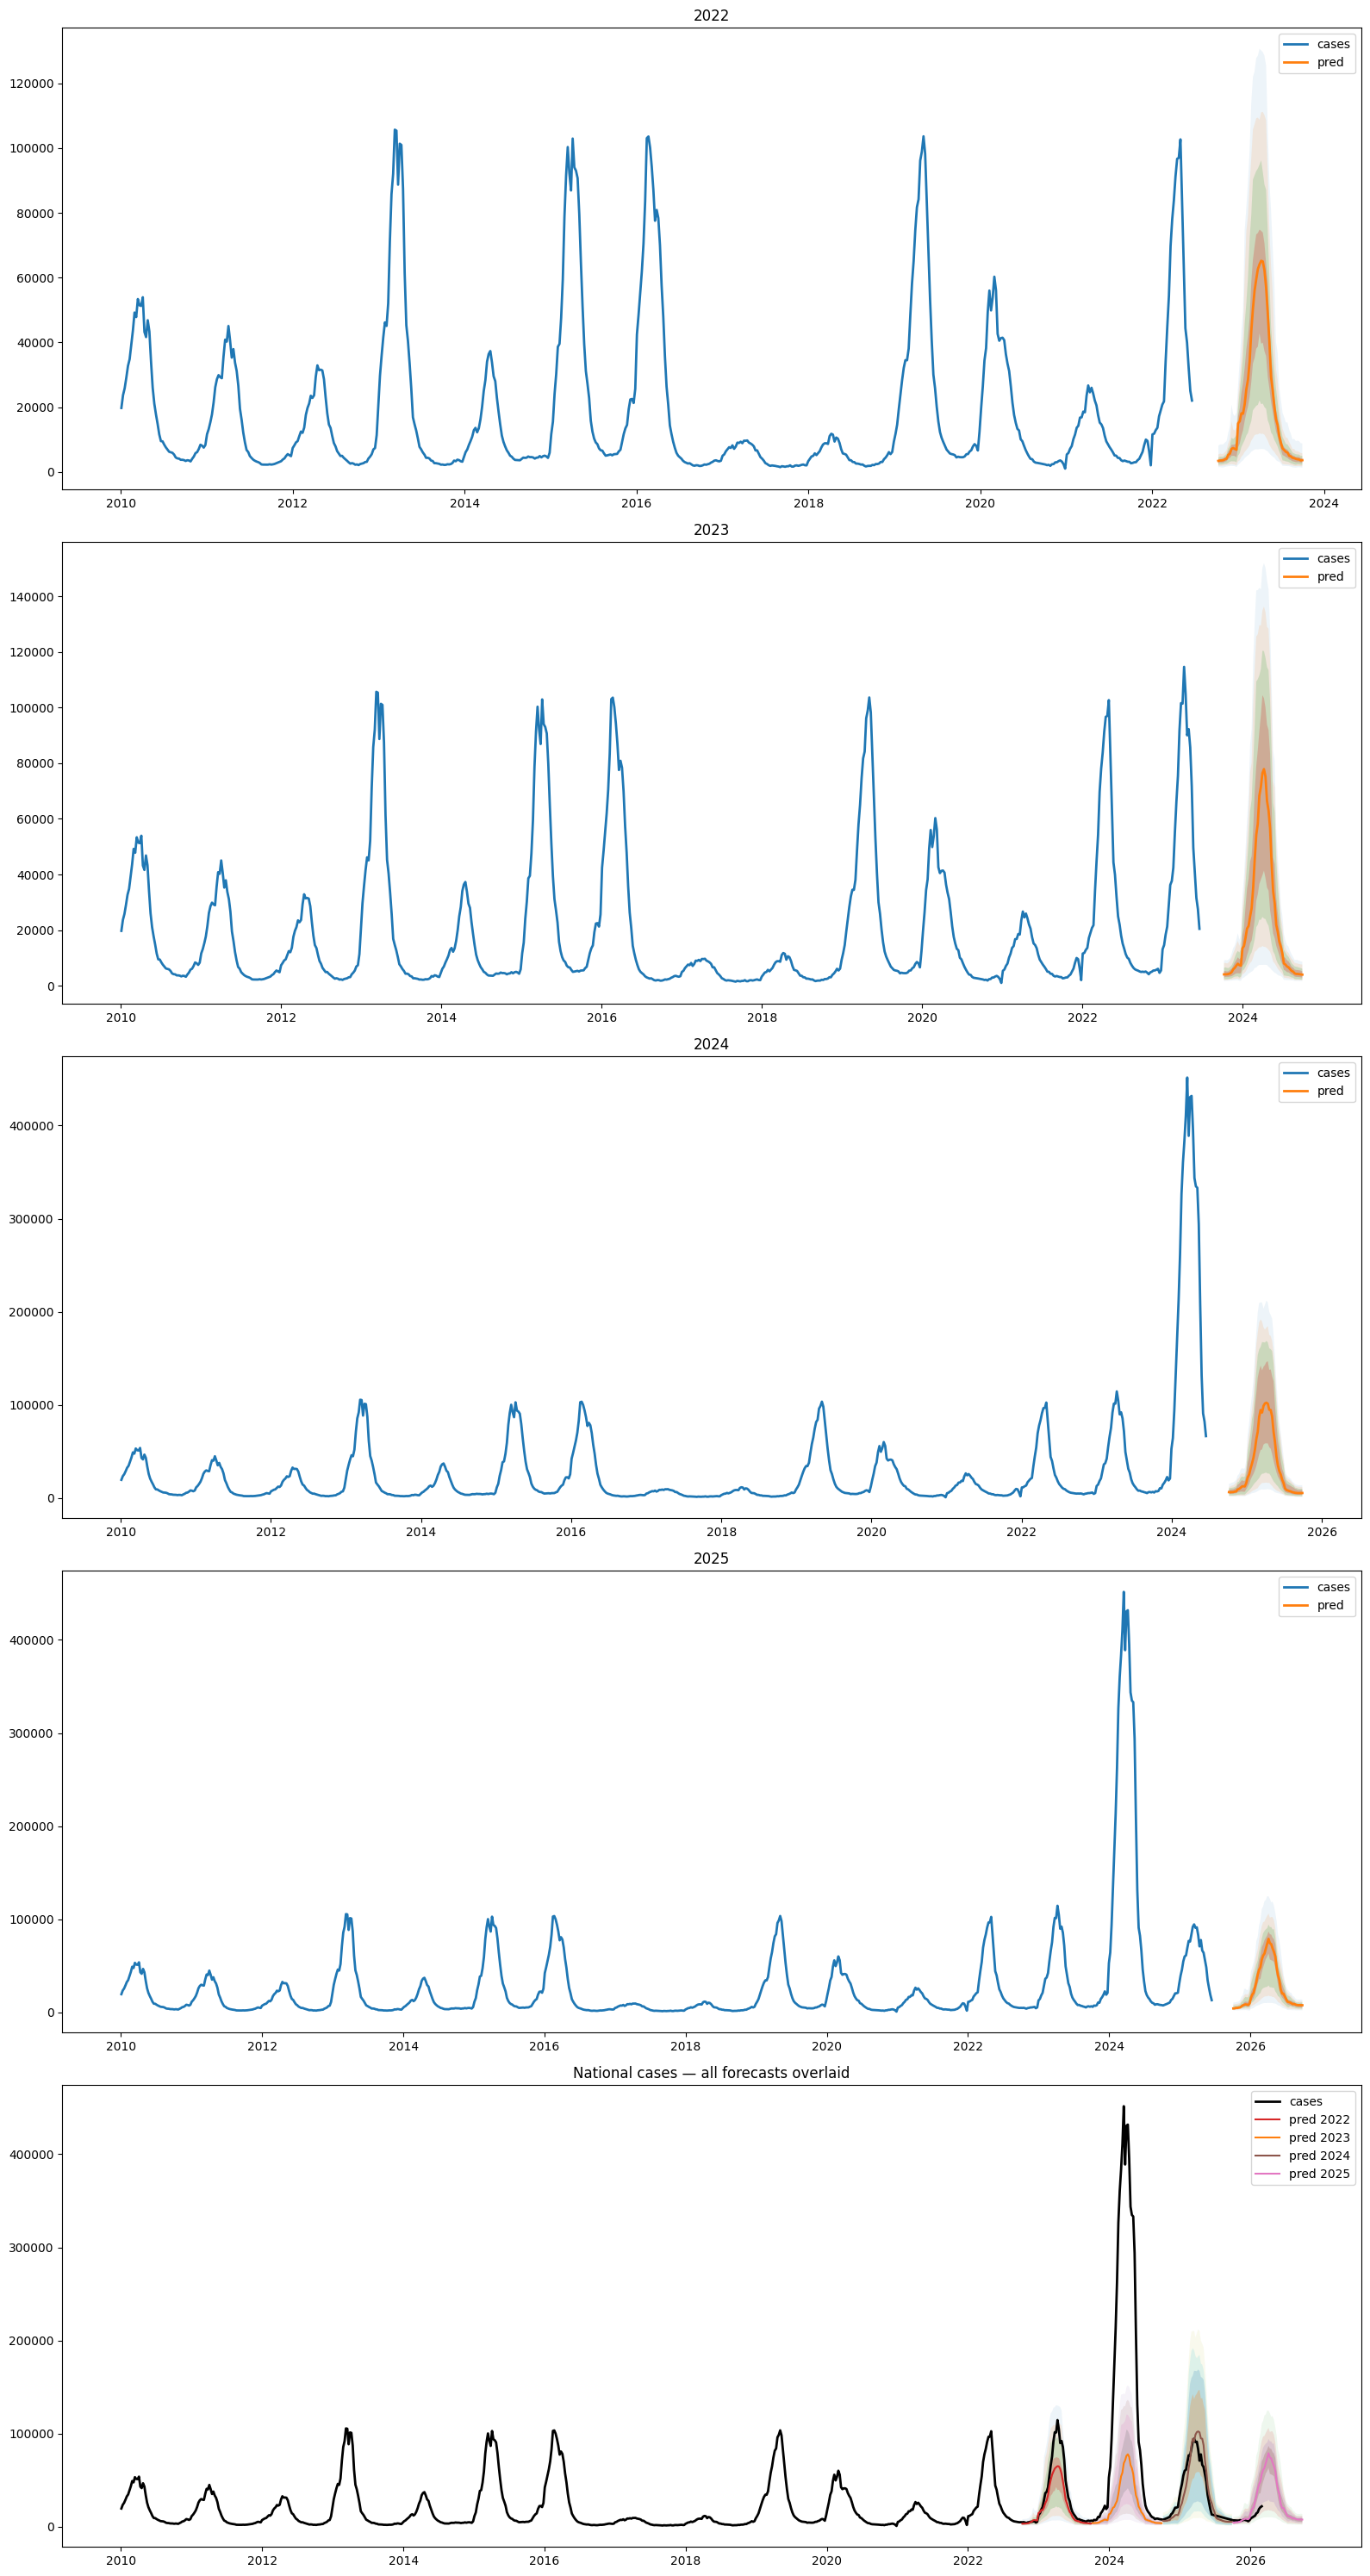

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(16, 30))
national_preds = {}

def plot(ax, x, y, label):
    ax.plot(pd.to_datetime(x), np.asarray(y), label=label, linewidth=2)

for TAG in range(1, 5):
    ax = axes[TAG - 1]

    x, y = df_module.data_factory(TAG)
    y = y[['uf_code', 'date', 'cases']]
    x = x[['uf_code', 'date', 'cases']]

    pred = pd.read_csv(f"results/baseline/ds{TAG}_submission.csv")
    pred = pred[~pred["date"].isin(pred["date"].drop_duplicates().head(15))]

    y = y.sort_values("date")
    y = y[~y["date"].isin(y["date"].drop_duplicates().iloc[:15])]

    df = pd.concat([x, y], ignore_index=True)
    keys = pd.concat([df[["uf_code", "date"]], pred[["uf_code", "date"]]]).drop_duplicates()

    df_full = keys.merge(df, on=["uf_code", "date"], how="left") \
                  .merge(pred, on=["uf_code", "date"], how="left", suffixes=("", "_pred"))

    for c in pred.columns:
        if c not in ["uf_code", "date"]:
            df_full[c] = df_full.get(c + "_pred", df_full.get(c))

    df_full = df_full.drop(columns=[c for c in df_full if c.endswith("_pred")])

    df_national = (
        df_full.drop(columns="uf_code")
        .groupby("date", as_index=False)
        .sum(min_count=df_full["uf_code"].nunique())
        .sort_values("date")
    )

    df_national["date"] = pd.to_datetime(df_national["date"])
    df_national = df_national.set_index("date").asfreq("W").reset_index()

    df_national.loc[df_national["pred"].notna(), "cases"] = np.nan
    national_preds[TAG] = df_national

    plot(ax, df_national["date"], df_national["cases"], "cases")
    plot(ax, df_national["date"], df_national["pred"], "pred")

    ax.fill_between(df_national["date"], df_national["lower_95"], df_national["upper_95"], alpha=0.08)
    ax.fill_between(df_national["date"], df_national["lower_90"], df_national["upper_90"], alpha=0.12)
    ax.fill_between(df_national["date"], df_national["lower_80"], df_national["upper_80"], alpha=0.18)
    ax.fill_between(df_national["date"], df_national["lower_50"], df_national["upper_50"], alpha=0.25)

    ax.set_title(f"{year_map[TAG]}")
    ax.legend()

ax5 = axes[4]

base = df_module.data_factory(4)
national = (
    pd.concat(base, axis=0)
    .assign(date=lambda d: pd.to_datetime(d["date"]),
            cases=lambda d: pd.to_numeric(d["cases"]))
    .groupby("date", as_index=False)["cases"]
    .sum(min_count=1)
    .iloc[:-1]
)

ax5.plot(national["date"], national["cases"], color="black", linewidth=2, label="cases")

colors = {1: "tab:red", 2: "tab:orange", 3: "tab:brown", 4: "tab:pink"}

for TAG in range(1, 5):
    dfn = national_preds[TAG]

    ax5.plot(dfn["date"], dfn["pred"], color=colors[TAG], label=f"pred {year_map[TAG]}")
    ax5.fill_between(dfn["date"], dfn["lower_95"], dfn["upper_95"], alpha=0.08)
    ax5.fill_between(dfn["date"], dfn["lower_90"], dfn["upper_90"], alpha=0.12)
    ax5.fill_between(dfn["date"], dfn["lower_80"], dfn["upper_80"], alpha=0.18)
    ax5.fill_between(dfn["date"], dfn["lower_50"], dfn["upper_50"], alpha=0.25)

ax5.set_title("National cases — all forecasts overlaid")
ax5.legend()

plt.tight_layout()
plt.show()